# IFN680 Assessment 2 - Chest X-Ray Pneumonia Detection

## Convolutional Neural Networks
### Karan Rooprai - N12498122

### Loading Data and splitting

In [1]:
import torchvision.transforms as transforms
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch

import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from tqdm import tqdm

torch.manual_seed(0)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose(
    [transforms.Grayscale(),
     transforms.ToTensor(),
     transforms.Normalize((0.5), (0.5)),
    ])


trainval_dataset = torchvision.datasets.ImageFolder('chest_xray/trainval', transform = transform)
train_portion = 0.8
val_portion = 0.2

all_indexes = np.arange(len(trainval_dataset))
all_targets = trainval_dataset.targets

train_idx, val_idx = train_test_split(all_indexes, train_size=train_portion, stratify = all_targets, random_state = 0)

train_dataset = torch.utils.data.Subset(trainval_dataset, train_idx)
val_dataset = torch.utils.data.Subset(trainval_dataset, val_idx)

test_dataset = torchvision.datasets.ImageFolder('chest_xray/test', transform = transform)

batch_size = 8 #Tuning --> [8, 16, 32, 64]

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers = 2)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                          shuffle=False, num_workers = 2)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=False, num_workers = 2)


In [2]:
trainval_dataset.classes

['NORMAL', 'PNEUMONIA']

In [3]:
trainval_dataset.class_to_idx

{'NORMAL': 0, 'PNEUMONIA': 1}

In [4]:
test_dataset.classes

['NORMAL', 'PNEUMONIA']

In [5]:
test_dataset.class_to_idx

{'NORMAL': 0, 'PNEUMONIA': 1}

In [6]:
print(f'Size of trainval dataset: {len(trainval_dataset)}')
print(f'Size of train dataset: {len(train_dataset)}')
print(f'Size of val dataset: {len(val_dataset)}')
print(f'Size of test dataset: {len(test_dataset)}')

Size of trainval dataset: 1234
Size of train dataset: 987
Size of val dataset: 247
Size of test dataset: 588


## Model

In [7]:
from model import VGG

net = VGG(num_classes=2)
net = net.to(device)
print(net)


VGG(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## Loss Function

In [8]:
loss_fn = nn.CrossEntropyLoss()

## Optimiser

In [9]:
learning_rate = 0.0001 # [0.1, 0.01, 0.001, 0.0001]
# weight_decay= 1e-4
optimizer = optim.Adam(params=net.parameters(), lr=learning_rate)


## Training Model

In [10]:
torch.manual_seed(0)

nb_epochs = 60
train_loss = []
train_acc = []
val_loss = []
val_acc = []

for epoch in tqdm(range(nb_epochs), total=nb_epochs, colour='blue'):
    # Training with Dropout on
    net.train()
    epoch_loss = []
    epoch_acc = []
    total_samples = 0
    for data in trainloader:
        
        optimizer.zero_grad()
    
        inputs, labels = data
        current_batch_size = len(labels)
        total_samples += current_batch_size

        
        x = inputs.to(device)
        y = labels.to(device)

        
        pred = net(x)
        
        pred_class = torch.argmax(pred, axis=1)
        
        acc_tr = (pred_class == y).sum() / len(pred_class)

        # computing loss
        loss = loss_fn(pred, y)
        # backward pass
        loss.backward()
        # updating weights
        optimizer.step()

    
        epoch_loss += [loss.item() * current_batch_size]
        epoch_acc += [float(acc_tr.detach()) * current_batch_size]
    mean_loss = np.array(epoch_loss).sum() / total_samples
    mean_acc = np.array(epoch_acc).sum() / total_samples

    # Validating with Dropout off
    net.eval()
    epoch_val_loss = []
    epoch_val_acc = []
    total_samples = 0
    for data in valloader:
        
        with torch.no_grad():
            inputs, labels = data
            current_batch_size = len(labels)
            total_samples += current_batch_size

            x = inputs.to(device)
            y = labels.to(device)

            pred = net(x)
            pred_class = torch.argmax(pred, axis=1)
            acc_val = (pred_class == y).sum() / len(pred_class)
            loss = loss_fn(pred, y)

            epoch_val_loss += [loss.item() * current_batch_size]
            epoch_val_acc += [float(acc_val.detach()) * current_batch_size]
    mean_val_loss = np.array(epoch_val_loss).sum() / total_samples
    mean_val_acc = np.array(epoch_val_acc).sum() / total_samples

    train_loss += [mean_loss]
    train_acc += [mean_acc]
    val_loss += [mean_val_loss]
    val_acc += [mean_val_acc]


    print(f'Epoch {epoch+1:2d}/{nb_epochs} | train loss: {mean_loss:.4f} acc: {mean_acc:.4f} | val loss: {mean_val_loss:.4f} acc: {mean_val_acc:.4f}')


  2%|▏         | 1/60 [00:02<01:58,  2.01s/it]

Epoch  1/60 | train loss: 0.6947 acc: 0.5491 | val loss: 0.6889 acc: 0.5506


  3%|▎         | 2/60 [00:03<01:35,  1.65s/it]

Epoch  2/60 | train loss: 0.5809 acc: 0.7021 | val loss: 0.3834 acc: 0.8300


  5%|▌         | 3/60 [00:04<01:28,  1.55s/it]

...

Epoch 58/60 | train loss: 0.0000 acc: 1.0000 | val loss: 0.5008 acc: 0.9393


 98%|█████████▊| 59/60 [01:20<00:01,  1.25s/it]

Epoch 59/60 | train loss: 0.0000 acc: 1.0000 | val loss: 0.5195 acc: 0.9393


100%|██████████| 60/60 [01:21<00:00,  1.36s/it]

Epoch 60/60 | train loss: 0.0000 acc: 1.0000 | val loss: 0.5247 acc: 0.9393


### Visualisation

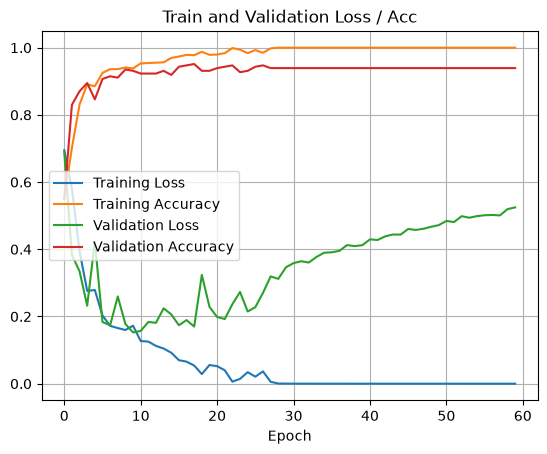

In [11]:
plt.title('Train and Validation Loss / Acc')

plt.plot(train_loss, label='Training Loss')
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_loss, label='Validation Loss')
plt.plot(val_acc, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.legend()
plt.grid()
plt.show()


### Performance on validation

In [12]:
from sklearn.metrics import classification_report

net.eval()
gt_val = []
val_pred = []
for data in valloader:
    with torch.no_grad():
        inputs, labels = data
        x = inputs.to(device)
        pred = net(x)
        predicted = torch.argmax(pred, axis=1)
        val_pred += predicted.cpu().tolist()
        gt_val += labels.cpu().tolist()

print(classification_report(gt_val, val_pred, target_names=trainval_dataset.classes, digits=4))


              precision    recall  f1-score   support

      NORMAL     0.9706    0.8919    0.9296       111
   PNEUMONIA     0.9172    0.9779    0.9466       136

    accuracy                         0.9393       247
   macro avg     0.9439    0.9349    0.9381       247
weighted avg     0.9412    0.9393    0.9390       247



## Saving best VGG model

In [13]:
torch.save(net.state_dict(), 'vgg.pth')

torch.save({'train_loss': [float(v) for v in train_loss],
            'val_loss': [float(v) for v in val_loss],
            'train_acc': [float(v) for v in train_acc],
            'val_acc': [float(v) for v in val_acc],
            'nb_epochs': nb_epochs,
            'learning_rate': learning_rate,
            'batch_size': batch_size}, 'history.pth')

print('Saved vgg.pth and history.pth')

Saved vgg.pth and history.pth


## Sanity Check!

In [14]:
from model import load_vgg

vgg = load_vgg()
vgg.eval()
vgg.to(device)
print("Model reloaded successfully from vgg.pth")


Model reloaded successfully from vgg.pth
